# Mosaic algorithm, step by step

One plot per step. Same engine as `mosaic_recipe.ipynb`, `mosaic.py`.

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.cm as cm
import windIO
import xarray as xr
from pyproj import Transformer
from scipy import ndimage
from scipy.spatial import cKDTree
from shapely.geometry import Polygon, box
from shapely.ops import unary_union
from shapely.vectorized import contains as shapely_contains

import mosaic

DATA_DIR = Path("..") / ".." / "Data"
SLA_PATH = Path("..") / ".." / "WindFarms" / "US_Cluster" / "Data" / "Federal_State_Boundary_SLA.geojson"

FIXED_BOTTOM_MAX_DEPTH = 80.0
BATHY_SMOOTH_M = 2_000.0
RESOLUTION_M = 300.0
RADIUS_KM = 150.0
BUFFER_CELLS = 3
CLUSTER_BUFFER_M = 1_000.0
FRAGMENT_AREA_KM2 = 30.0
SEED = 7

# raw inputs
site_us = windIO.load_yaml(DATA_DIR / "site_us.yaml")
boundary_polygons = site_us["boundaries"]["polygons"]
boundary_names = [
    "Vineyard Wind", "Revolution Wind", "SouthCoast Wind", "South Fork Wind",
    "Sunrise Wind South", "Sunrise Wind North", "Revolution Wind North",
    "Vineyard Northeast", "New England Wind 1", "New England Wind 2 South",
    "Beacon Wind", "Bay State Wind South", "Bay State Wind North",
]
lease_templates = {name: Polygon(zip(p["x"], p["y"])) for name, p in zip(boundary_names, boundary_polygons)}

wind_farm_us = windIO.load_yaml(DATA_DIR / "wind_farm_us.yaml")
vineyard = next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")
vineyard_center = np.array([
    np.mean(vineyard["layouts"][0]["coordinates"]["x"]),
    np.mean(vineyard["layouts"][0]["coordinates"]["y"]),
])

bathy = xr.open_dataset(DATA_DIR / "bathymetry_us.nc")
bathy_xy = np.column_stack([bathy["x"].values, bathy["y"].values])
bathy_depth = bathy["depth"].values
bathy_tree = cKDTree(bathy_xy)

sla_raw = json.load(open(SLA_PATH))["features"][0]["geometry"]["coordinates"]
lon_min, lon_max, lat_min, lat_max = -73.0, -68.5, 40.0, 43.0
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)
sla_lines_utm = []
for line in sla_raw:
    pts = np.array(line)
    mask = (pts[:, 0] >= lon_min) & (pts[:, 0] <= lon_max) & (pts[:, 1] >= lat_min) & (pts[:, 1] <= lat_max)
    if mask.sum() < 2:
        continue
    sub = pts[mask]
    x, y = to_utm.transform(sub[:, 0], sub[:, 1])
    sla_lines_utm.append(np.column_stack([x, y]))
sla_all = np.vstack(sla_lines_utm)
tangents = np.zeros_like(sla_all)
offset = 0
for line in sla_lines_utm:
    n = len(line)
    tangents[offset:offset + n] = np.gradient(line, axis=0)
    offset += n
sla_tree = cKDTree(sla_all)

def sla_side(xs, ys):
    pts = np.column_stack([xs, ys])
    _, idx = sla_tree.query(pts)
    vec = pts - sla_all[idx]
    cross = tangents[idx, 0] * vec[:, 1] - tangents[idx, 1] * vec[:, 0]
    return np.sign(cross)

federal_sign = np.sign(sla_side(np.array([vineyard_center[0]]), np.array([vineyard_center[1]])).mean())

# working grid
R = RADIUS_KM * 1000
margin = 5_000.0
all_x = np.concatenate([np.array(p["x"]) for p in boundary_polygons])
all_y = np.concatenate([np.array(p["y"]) for p in boundary_polygons])
x0 = min(vineyard_center[0] - R - margin, all_x.min() - margin)
x1 = max(vineyard_center[0] + R + margin, all_x.max() + margin)
y0 = min(vineyard_center[1] - R - margin, all_y.min() - margin)
y1 = max(vineyard_center[1] + R + margin, all_y.max() + margin)
nx = int((x1 - x0) / RESOLUTION_M) + 1
ny = int((y1 - y0) / RESOLUTION_M) + 1
gx = x0 + np.arange(nx) * RESOLUTION_M
gy = y0 + np.arange(ny) * RESOLUTION_M
GX, GY = np.meshgrid(gx, gy, indexing="xy")
GXf, GYf = GX.ravel(), GY.ravel()
EXTENT_KM = [x0 / 1000, x1 / 1000, y0 / 1000, y1 / 1000]

def new_ax(figsize=(8, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_xlabel("km"); ax.set_ylabel("km")
    return fig, ax

The federal border.

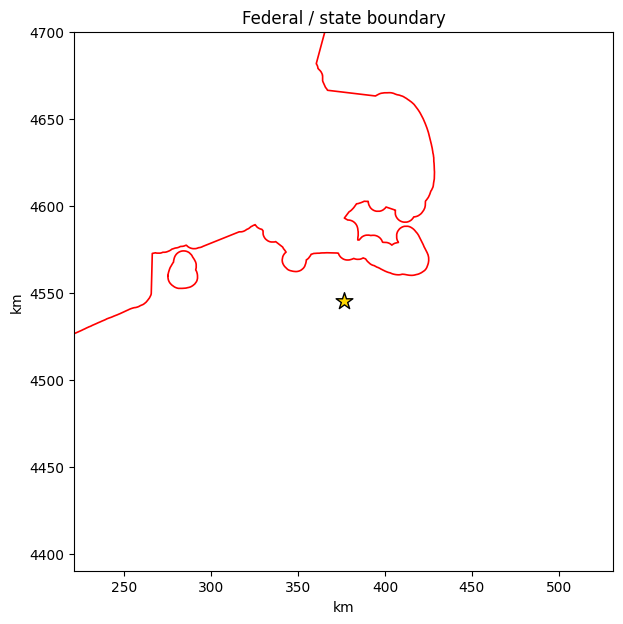

In [2]:
fig, ax = new_ax()
for line in sla_lines_utm:
    ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=1.2)
ax.scatter(*(vineyard_center / 1000), marker="*", s=160, color="gold", edgecolor="black", zorder=5)
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
ax.set_title("Federal / state boundary")
plt.show()

Bathymetry in this area.

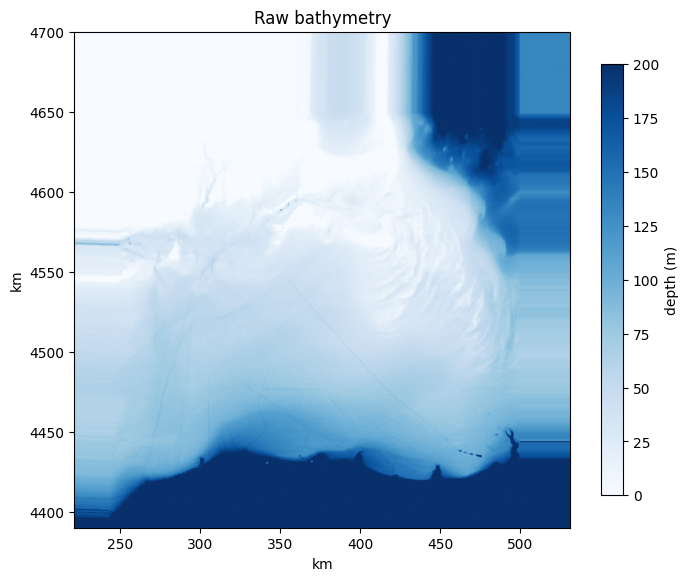

In [3]:
_, bidx = bathy_tree.query(np.column_stack([GXf, GYf]))
depth_grid = bathy_depth[bidx].reshape(GX.shape)

fig, ax = new_ax()
im = ax.imshow(depth_grid, origin="lower", extent=EXTENT_KM, cmap="Blues", vmax=200)
fig.colorbar(im, ax=ax, label="depth (m)", shrink=0.8)
ax.set_title("Raw bathymetry")
plt.show()

Raw depth data is noisy at 300m resolution. We smooth it before cutting at 80m.

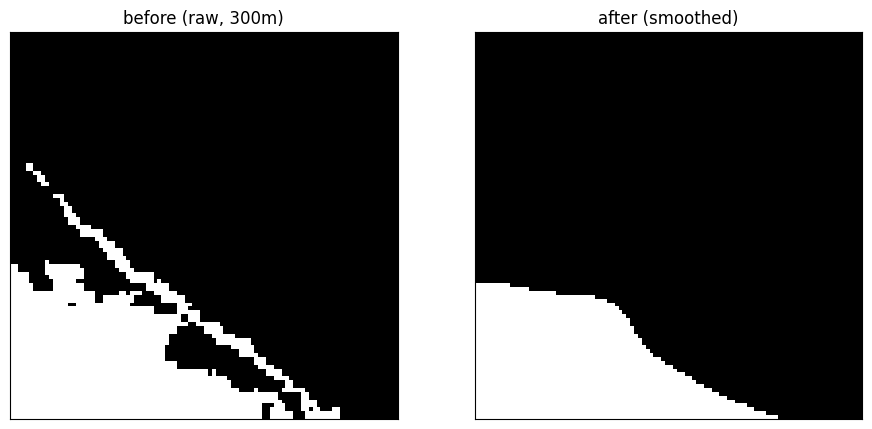

In [4]:
depth_grid_smooth = ndimage.gaussian_filter(depth_grid, sigma=BATHY_SMOOTH_M / RESOLUTION_M)
raw_shallow = depth_grid < FIXED_BOTTOM_MAX_DEPTH
smooth_shallow = depth_grid_smooth < FIXED_BOTTOM_MAX_DEPTH

diff_iy, diff_ix = np.nonzero(raw_shallow != smooth_shallow)
cyi, cxi = int(np.median(diff_iy)), int(np.median(diff_ix))
half = int(15_000 / RESOLUTION_M)
sl = (slice(max(cyi - half, 0), cyi + half), slice(max(cxi - half, 0), cxi + half))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(raw_shallow[sl], origin="lower", cmap="Greys")
axes[0].set_title("before (raw, 300m)")
axes[1].imshow(smooth_shallow[sl], origin="lower", cmap="Greys")
axes[1].set_title("after (smoothed)")
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.show()

Federal water + shallow water combined.

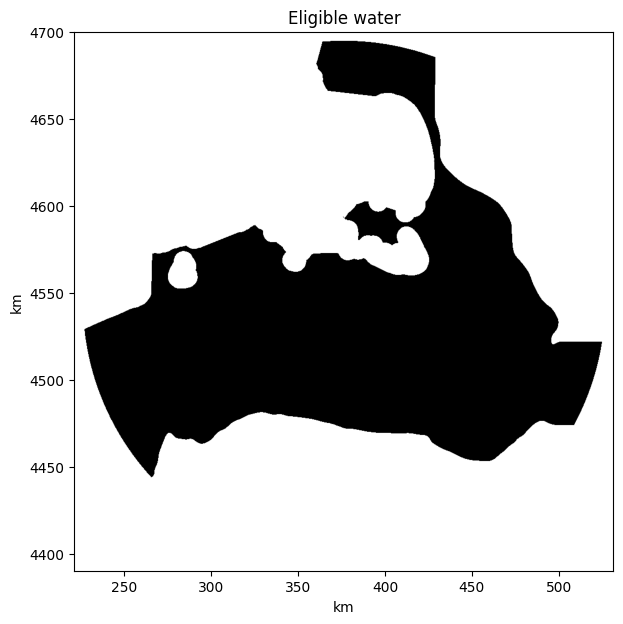

In [5]:
fed = (sla_side(GXf, GYf) == federal_sign).reshape(GX.shape)
within_radius = np.hypot(GX - vineyard_center[0], GY - vineyard_center[1]) < R
eligible_no_cluster = fed & smooth_shallow & within_radius

fig, ax = new_ax()
ax.imshow(eligible_no_cluster, origin="lower", extent=EXTENT_KM, cmap="Greys")
ax.set_title("Eligible water")
plt.show()

Exclude the existing cluster as one shape, not 13 separate ones.

/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_61404/1566608560.py:2: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  eligible = eligible_no_cluster & ~shapely_contains(cluster_shape, GX, GY)


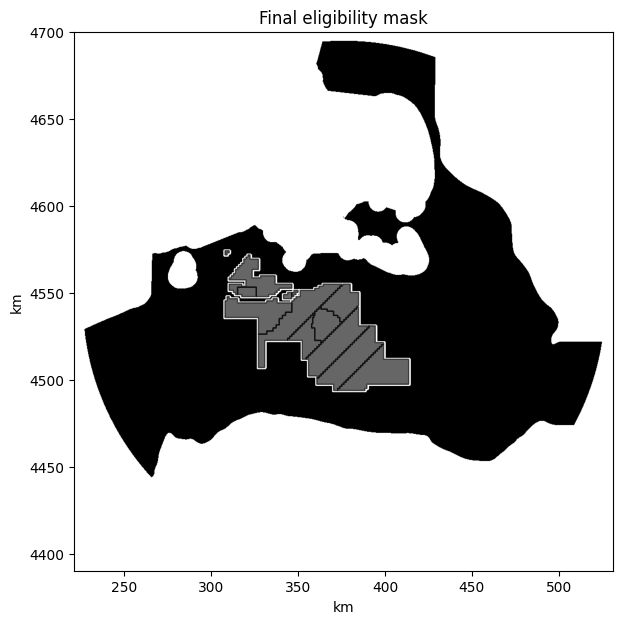

27,120 km2 eligible


In [6]:
cluster_shape = unary_union(list(lease_templates.values())).buffer(CLUSTER_BUFFER_M)
eligible = eligible_no_cluster & ~shapely_contains(cluster_shape, GX, GY)

fig, ax = new_ax()
ax.imshow(eligible, origin="lower", extent=EXTENT_KM, cmap="Greys")
for poly in lease_templates.values():
    bx, by = poly.exterior.xy
    ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color="black", alpha=0.6)
ax.set_title("Final eligibility mask")
plt.show()

eligible_area_km2 = eligible.sum() * (RESOLUTION_M / 1000.0) ** 2
print(f"{eligible_area_km2:,.0f} km2 eligible")

Scatter points with a minimum gap between them (Poisson-disk sampling).

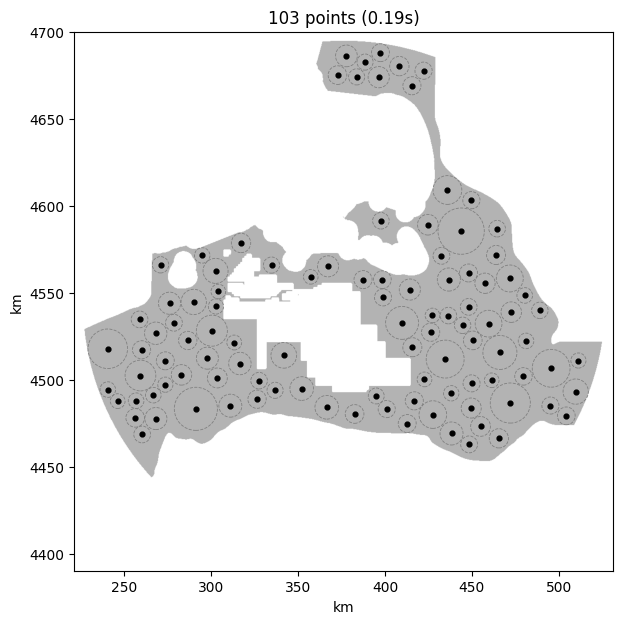

In [7]:
areas = np.array([p.area / 1e6 for p in lease_templates.values()])
r_eq_km = np.sqrt(areas[areas >= FRAGMENT_AREA_KM2] / np.pi)
r_min, r_max = r_eq_km.min() * 1000.0, r_eq_km.max() * 1000.0

rng = np.random.default_rng(SEED)
t0 = time.time()
points, radii = mosaic.sample_variable_poisson_disk(eligible, x0, y0, RESOLUTION_M, r_min, r_max, rng)
t_sample = time.time() - t0

fig, ax = new_ax()
ax.imshow(eligible, origin="lower", extent=EXTENT_KM, cmap="Greys", alpha=0.3)
for (px, py), r in zip(points, radii):
    ax.add_patch(Circle((px / 1000, py / 1000), r / 1000, fill=False, linestyle="--", linewidth=0.6, color="gray"))
ax.scatter(points[:, 0] / 1000, points[:, 1] / 1000, s=12, color="black", zorder=5)
ax.set_title(f"{len(points)} points ({t_sample:.2f}s)")
plt.show()

Grow each point into its own territory (weighted Voronoi).

/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_61404/2823973290.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cat = cm.get_cmap("tab20").copy()


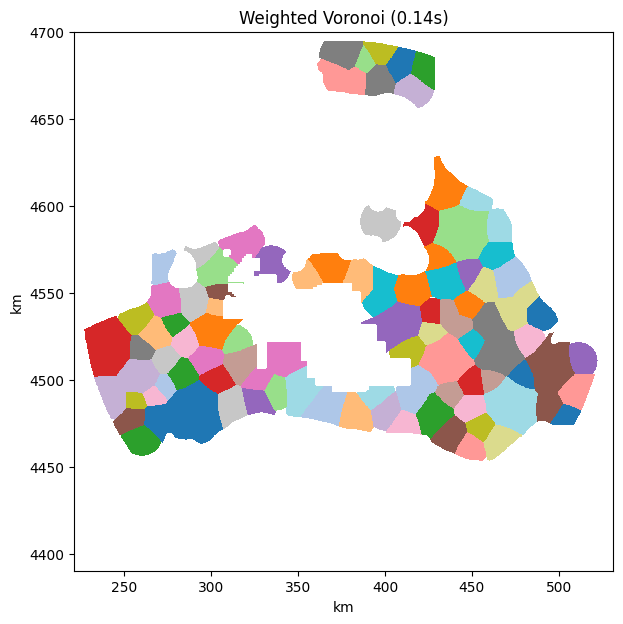

In [8]:
t0 = time.time()
label_raw = mosaic.label_weighted_voronoi(eligible, x0, y0, RESOLUTION_M, points, radii)
t_voronoi = time.time() - t0

shown = np.ma.masked_where(label_raw < 0, label_raw % 20)
cmap_cat = cm.get_cmap("tab20").copy()
cmap_cat.set_bad("white")

fig, ax = new_ax()
ax.imshow(shown, origin="lower", extent=EXTENT_KM, cmap=cmap_cat, interpolation="nearest")
ax.set_title(f"Weighted Voronoi ({t_voronoi:.2f}s)")
plt.show()

Raw cells still touch -- add a gap between neighbors.

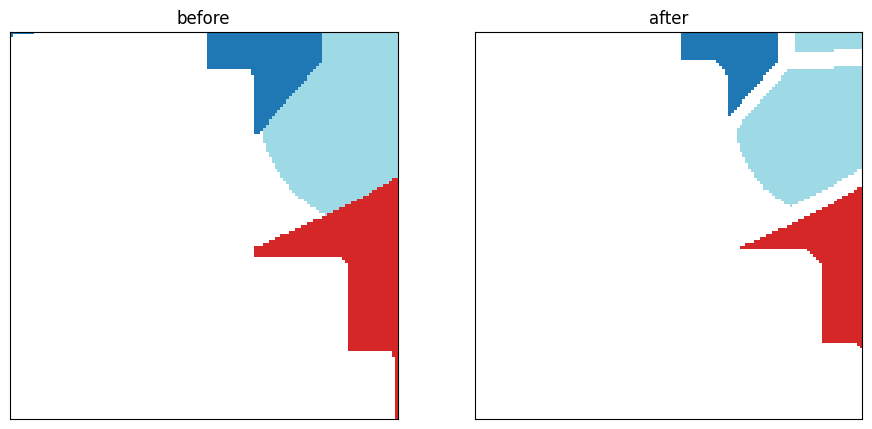

In [9]:
label_buffered = mosaic.apply_gap_buffer(label_raw, buffer_cells=BUFFER_CELLS)

cy_km, cx_km = points[:, 1].mean(), points[:, 0].mean()
half = int(20_000 / RESOLUTION_M)
cyi = int((cy_km - y0) / RESOLUTION_M)
cxi = int((cx_km - x0) / RESOLUTION_M)
sl = (slice(max(cyi - half, 0), cyi + half), slice(max(cxi - half, 0), cxi + half))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for a, lab, title in zip(axes, [label_raw, label_buffered], ["before", "after"]):
    shown = np.ma.masked_where(lab[sl] < 0, lab[sl] % 20)
    a.imshow(shown, origin="lower", cmap=cmap_cat, interpolation="nearest")
    a.set_title(title); a.set_xticks([]); a.set_yticks([])
plt.show()

Fix any parcel that got split in two.

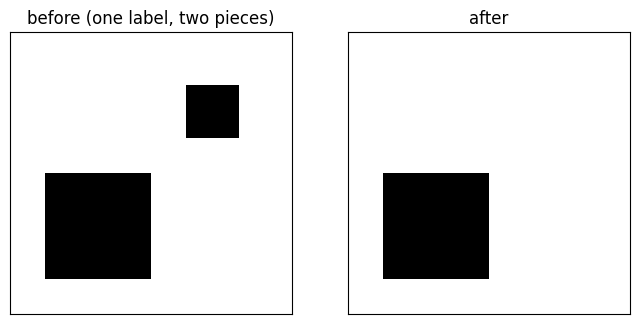

In [10]:
# Example, not from the real mosaic -- built here just to show what this step catches.
example = np.full((16, 16), -1, dtype=np.int32)
example[2:8, 2:8] = 0      # bigger piece -- kept
example[10:13, 10:13] = 0  # smaller piece, same label, not touching -- dropped

fixed = mosaic.clean_labels(example, min_cells=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))
for a, lab, title in zip(axes, [example, fixed], ["before (one label, two pieces)", "after"]):
    shown = np.ma.masked_where(lab < 0, lab)
    a.imshow(shown, origin="lower", cmap="Greys_r", interpolation="nearest")
    a.set_title(title); a.set_xticks([]); a.set_yticks([])
plt.show()

Turn grid cells into an actual polygon.

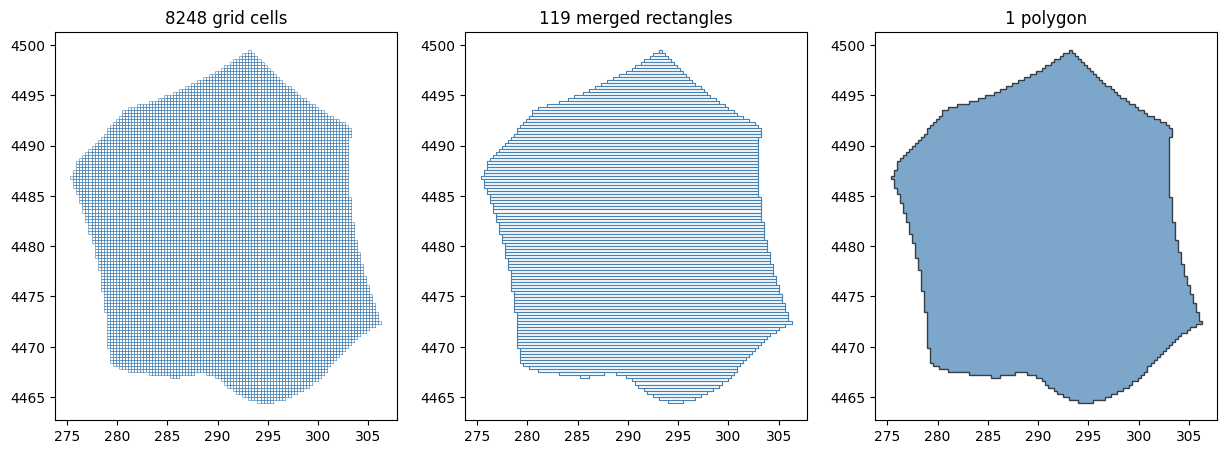

In [11]:
label_clean = mosaic.clean_labels(label_buffered)
example_id = int(np.bincount((label_clean[label_clean >= 0]).astype(int)).argmax())
iy, ix = np.nonzero(label_clean == example_id)

cell_boxes = [box(x0 + x * RESOLUTION_M, y0 + y * RESOLUTION_M,
                   x0 + (x + 1) * RESOLUTION_M, y0 + (y + 1) * RESOLUTION_M) for x, y in zip(ix, iy)]
rows, x_starts, x_ends = mosaic._row_runs(iy, ix)
run_boxes = [box(x0 + xs * RESOLUTION_M, y0 + r * RESOLUTION_M,
                  x0 + (xe + 1) * RESOLUTION_M, y0 + (r + 1) * RESOLUTION_M)
             for r, xs, xe in zip(rows, x_starts, x_ends)]
final_polygon = unary_union(run_boxes)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for a, b in zip(axes[:1], [cell_boxes]):
    pass
for bx in cell_boxes:
    xs, ys = bx.exterior.xy
    axes[0].plot(np.array(xs) / 1000, np.array(ys) / 1000, color="steelblue", linewidth=0.4)
axes[0].set_title(f"{len(cell_boxes)} grid cells")
for bx in run_boxes:
    xs, ys = bx.exterior.xy
    axes[1].plot(np.array(xs) / 1000, np.array(ys) / 1000, color="steelblue", linewidth=0.8)
axes[1].set_title(f"{len(run_boxes)} merged rectangles")
xs, ys = final_polygon.exterior.xy
axes[2].fill(np.array(xs) / 1000, np.array(ys) / 1000, color="steelblue", alpha=0.7, edgecolor="black")
axes[2].set_title("1 polygon")
for a in axes:
    a.set_aspect("equal")
plt.show()

Every parcel, converted.

/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_61404/1869722395.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cm.get_cmap("tab20")(pid % 20),


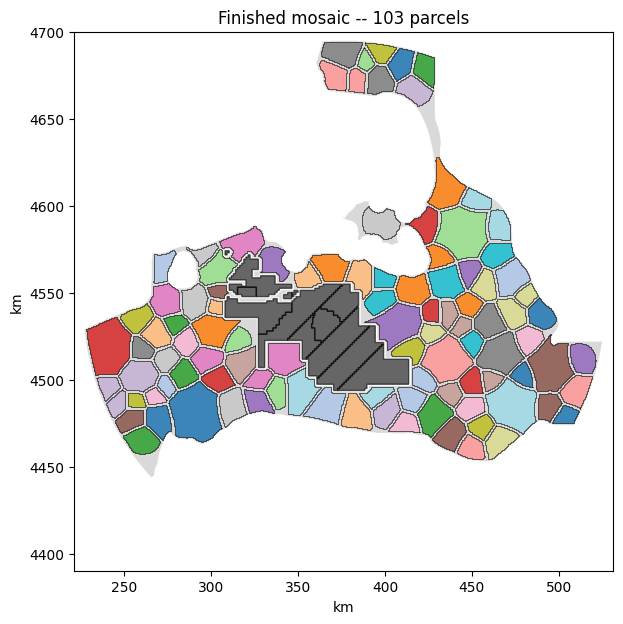

In [12]:
polygons = mosaic.polygons_from_labels(label_clean, x0, y0, RESOLUTION_M)

fig, ax = new_ax()
ax.imshow(eligible, origin="lower", extent=EXTENT_KM, cmap="Greys", alpha=0.15)
for pid, poly in polygons.items():
    if poly.is_empty:
        continue
    bx, by = poly.exterior.xy
    ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cm.get_cmap("tab20")(pid % 20),
            alpha=0.85, edgecolor="black", linewidth=0.5)
for poly in lease_templates.values():
    bx, by = poly.exterior.xy
    ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color="black", alpha=0.6)
ax.set_title(f"Finished mosaic -- {len(polygons)} parcels")
plt.show()